In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.3.5
pandas 3.0.0
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


# 数据预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 1. 首先只使用 ToTensor() 来计算均值和标准差
temp_transform = transforms.Compose([
    transforms.ToTensor(),
])

temp_train_dataset = datasets.FashionMNIST(
    root='../day20/data',
    train=True,
    download=True,
    transform=temp_transform
)

# 计算均值和标准差
# dataset.data 的形状是 (60000, 28, 28)，且是 uint8 类型 [0, 255]
# 我们需要将其转换为 float32 并归一化到 [0, 1]
train_data = temp_train_dataset.data.type(torch.float32) / 255.0
mean = train_data.mean().item()
std = train_data.std().item()

print(f"计算得到的均值: {mean:.4f}")
print(f"计算得到的标准差: {std:.4f}")

# 2. 定义包含标准化的数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))  # 使用计算出的均值和标准差
])

# 3. 使用最终的 transform 重新加载数据集
train_dataset = datasets.FashionMNIST(
    root='../day20/data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='../day20/data',
    train=False,
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练集数据类型: {type(train_dataset)}")
print(f"单个dataset元素类型: {type(train_dataset[0])}")
print(f"图像尺寸: {train_dataset[0][0].shape}")
# FashionMNIST类别标签
print(f"类别标签: {train_dataset.classes}")


计算得到的均值: 0.2860
计算得到的标准差: 0.3530
训练集大小: 60000
测试集大小: 10000
训练集数据类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
单个dataset元素类型: <class 'tuple'>
图像尺寸: torch.Size([1, 28, 28])
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 1875
测试集DataLoader批次数: 313
每个批次大小: 32
批次图像张量形状: torch.Size([32, 1, 28, 28])
批次标签张量形状: torch.Size([32])
tensor([1, 9, 1, 0, 5, 5, 2, 6, 8, 0, 5, 3, 3, 7, 1, 1, 8, 5, 7, 9, 3, 2, 8, 3,
        5, 1, 5, 2, 2, 1, 9, 8])


# 搭建模型

In [4]:
import torch.nn as nn

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # 输入 (batch, 1, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # (batch, 32, 28, 28)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # (batch, 32, 28, 28)
        self.pool = nn.MaxPool2d(2, 2)                           # (batch, 32, 14, 14)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (batch, 64, 14, 14)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # (batch, 64, 14, 14)
        
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (batch, 128, 7, 7)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1) # (batch, 128, 7, 7)
        
        self.selu = nn.SELU(inplace=True)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.selu(self.conv1(x))
        # print('After conv1+selu:', x.shape)
        x = self.selu(self.conv2(x))
        # print('After conv2+selu:', x.shape)
        x = self.pool(x)
        # print('After pool1:', x.shape)
        
        x = self.selu(self.conv3(x))
        # print('After conv3+selu:', x.shape)
        x = self.selu(self.conv4(x))
        # print('After conv4+selu:', x.shape)
        x = self.pool(x)
        # print('After pool2:', x.shape)
        
        x = self.selu(self.conv5(x))
        # print('After conv5+selu:', x.shape)
        x = self.selu(self.conv6(x))
        # print('After conv6+selu:', x.shape)
        x=self.pool(x)
        # print('After pool3:', x.shape)

        x = self.flatten(x)
        # print('After flatten:', x.shape)
        x = self.selu(self.fc1(x))
        # print('After fc1+selu:', x.shape)
        x = self.fc2(x)
        # print('After fc2:', x.shape)
        return x

# 实例化模型
model = FashionCNN()


In [5]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 1, 28, 28)  # batch_size=1, channels=1, height=28, width=28
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [6]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
conv1.weight: 288
conv1.bias: 32
conv2.weight: 9216
conv2.bias: 32
conv3.weight: 18432
conv3.bias: 64
conv4.weight: 36864
conv4.bias: 64
conv5.weight: 73728
conv5.bias: 128
conv6.weight: 147456
conv6.bias: 128
fc1.weight: 147456
fc1.bias: 128
fc2.weight: 1280
fc2.bias: 10
模型总参数量: 435306


# 训练

In [7]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 500] Val Loss: 0.4569 Val Acc: 0.8347
[Step 1000] Val Loss: 0.3462 Val Acc: 0.8688
[Step 1500] Val Loss: 0.3793 Val Acc: 0.8731
Epoch [1/20]  Train Loss: 0.4089  Train Acc: 0.8496
[Step 2000] Val Loss: 0.3379 Val Acc: 0.8779
[Step 2500] Val Loss: 0.3412 Val Acc: 0.8752
[Step 3000] Val Loss: 0.2791 Val Acc: 0.8974
[Step 3500] Val Loss: 0.3265 Val Acc: 0.8818
Epoch [2/20]  Train Loss: 0.2923  Train Acc: 0.8934
[Step 4000] Val Loss: 0.3373 Val Acc: 0.8803
[Step 4500] Val Loss: 0.2965 Val Acc: 0.8962
[Step 5000] Val Loss: 0.3085 Val Acc: 0.8943
[Step 5500] Val Loss: 0.2935 Val Acc: 0.8954
Epoch [3/20]  Train Loss: 0.2614  Train Acc: 0.9061
[Step 6000] Val Loss: 0.2816 Val Acc: 0.8997
[Step 6500] Val Loss: 0.2990 Val Acc: 0.8909
[Step 7000] Val Loss: 0.2794 Val Acc: 0.8966
[Step 7500] Val Loss: 0.2823 Val Acc: 0.9023
Epoch [4/20]  Train Loss: 0.2317  Train Acc: 0.9167
[Step 8000] Val Loss: 0.3283 Val Acc: 0.8898
[Step 8500] Val Loss: 0.3606 Val Acc: 0.8860
[Step 9000] Val Loss: 0.2737

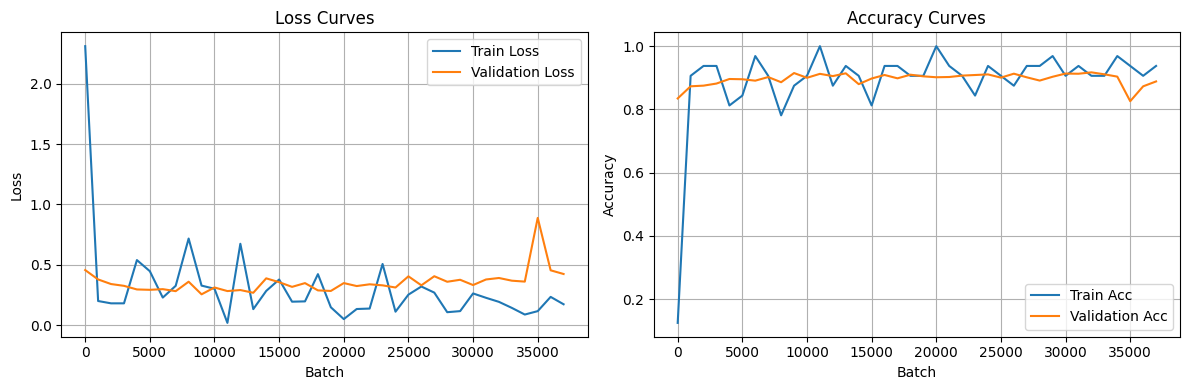

In [9]:
trainer.plot_curves()
